
--- Running Simulation for Digit: 0 ---


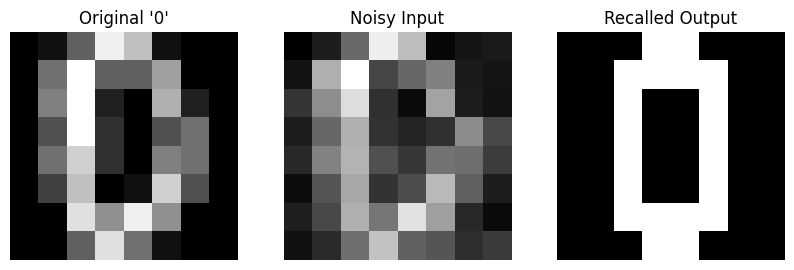

Tested Digit: 0 | Images Trained: 144 | Scale: 3.14

--- Running Simulation for Digit: 1 ---


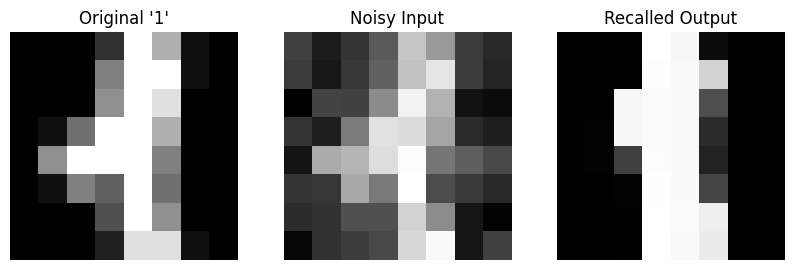

Tested Digit: 1 | Images Trained: 158 | Scale: 3.14

--- Running Simulation for Digit: 2 ---


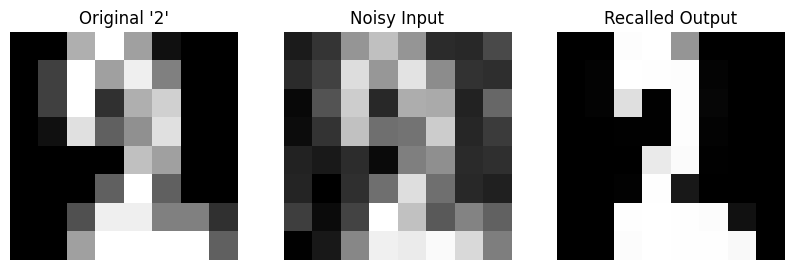

Tested Digit: 2 | Images Trained: 150 | Scale: 3.14

--- Running Simulation for Digit: 3 ---


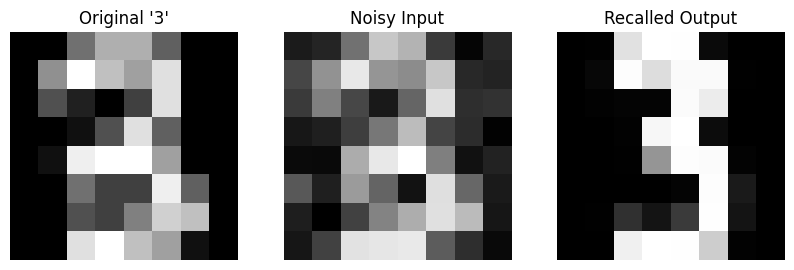

Tested Digit: 3 | Images Trained: 148 | Scale: 3.14

--- Running Simulation for Digit: 4 ---


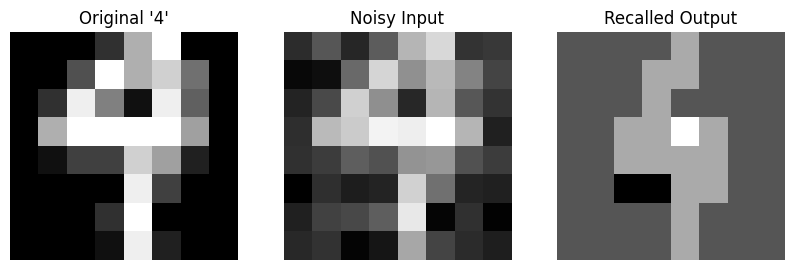

Tested Digit: 4 | Images Trained: 148 | Scale: 3.14

--- Running Simulation for Digit: 5 ---


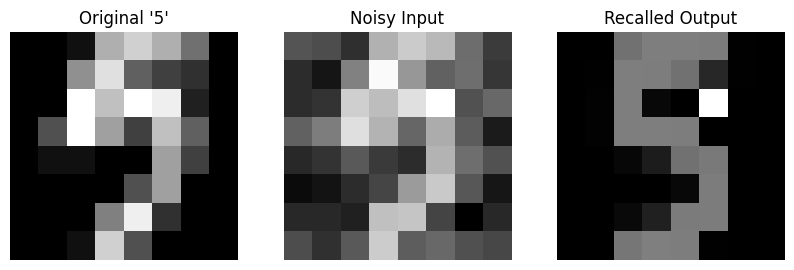

Tested Digit: 5 | Images Trained: 153 | Scale: 3.14

--- Running Simulation for Digit: 6 ---


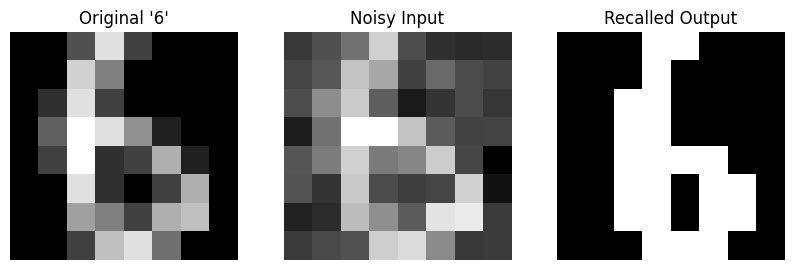

Tested Digit: 6 | Images Trained: 149 | Scale: 3.14

--- Running Simulation for Digit: 7 ---


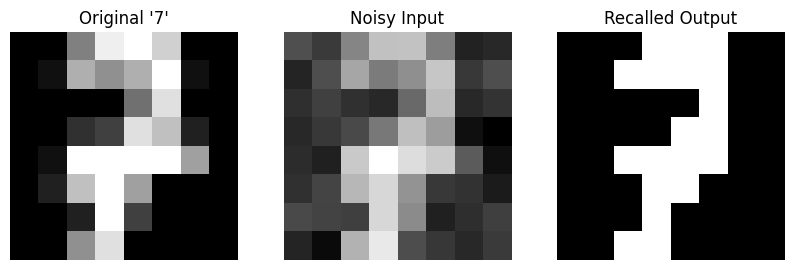

Tested Digit: 7 | Images Trained: 155 | Scale: 3.14

--- Running Simulation for Digit: 8 ---


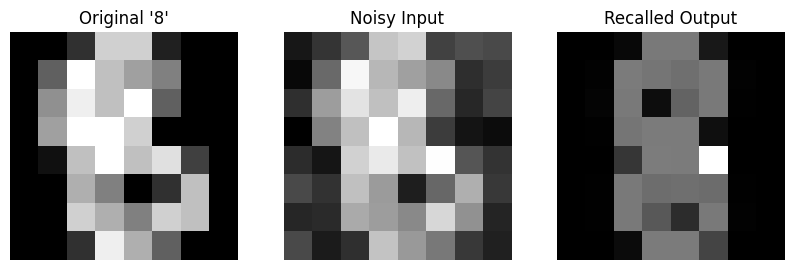

Tested Digit: 8 | Images Trained: 139 | Scale: 3.14

--- Running Simulation for Digit: 9 ---


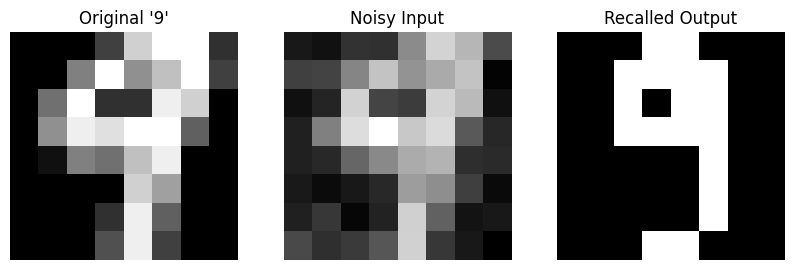

Tested Digit: 9 | Images Trained: 156 | Scale: 3.14


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Load Data
data = np.loadtxt('optdigits.tra', delimiter=',')
X_all = data[:1500, :64]
y_all = data[:1500, 64].astype(int)

def run_demo(digit_to_test, scale=np.pi, K=3.5, noise_level=0.5):
    # Filter for the specific digit's patterns
    digit_indices = np.where(y_all == digit_to_test)[0]
    X_digit = X_all[digit_indices]
    
    # Per-image Normalization to Phases
    x_min, x_max = X_digit.min(axis=1, keepdims=True), X_digit.max(axis=1, keepdims=True)
    denom = np.where(x_max - x_min == 0, 1, x_max - x_min)
    patterns = ((X_digit - x_min) / denom) * scale
    
    # 2. Hebbian Learning (Matrix Form)
    P, N = patterns.shape
    C, S = np.cos(patterns), np.sin(patterns)
    W = (C.T @ C + S.T @ S) / P 
    np.fill_diagonal(W, 0)
    W_scaled = K * W

    # 3. Create Noisy Input (using the first pattern of that digit)
    clean_target = patterns[0]
    noisy_input = clean_target + np.random.normal(0, noise_level, size=N)

    # 4. Kuramoto Dynamics
    def kuramoto(t, theta):
        return np.sum(W_scaled * np.sin(theta[None, :] - theta[:, None]), axis=1)

    # Solve and get final state
    sol = solve_ivp(kuramoto, [0, 100], noisy_input, t_eval=[100], method='RK45')
    recalled = sol.y[:, -1]

    # 5. Visualization
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    titles = [f"Original '{digit_to_test}'", "Noisy Input", "Recalled Output"]
    imgs = [clean_target, noisy_input, recalled]

    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(img.reshape(8,8), cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    plt.show()
    
    print(f"Tested Digit: {digit_to_test} | Images Trained: {P} | Scale: {scale:.2f}")

# --- TEST AREA ---

for digit in range(10):
    print(f"\n--- Running Simulation for Digit: {digit} ---")

    run_demo(digit_to_test=digit, scale=np.pi, K=3.5, noise_level=0.4)